## Colab Runtime Setup
Before running the rest of the notebook:
1. Go to **Runtime > Change runtime type** and select a **GPU** (T4 is fine).
2. Run the setup cells below to confirm the GPU is attached and clone/pull the latest `ECE1508` repo into local (ephemeral) storage.

Note: `drive.mount()` doesn't work when connected via VS Code's Colab integration (it needs the native browser UI to complete Google auth), so this session's checkpoints and downloaded MNIST data live only in `/content` and won't survive a runtime restart. Your workflow: edit locally → commit + push → re-run the clone/pull cell here → reopen the notebook tab if it was already open → run the rest.

In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [ ]:
import os

REPO_URL = "https://github.com/Stevey8/ECE1508.git"
BRANCH = "main"
repo_dir = "/content/ECE1508"

if not os.path.isdir(repo_dir):
    !git clone -b {BRANCH} {REPO_URL} {repo_dir}
else:
    !cd {repo_dir} && git pull

os.chdir(os.path.join(repo_dir, "a5"))
print(f"Working directory set to: {os.getcwd()}")

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 1), reused 4 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 179.45 KiB | 2.06 MiB/s, done.
From https://github.com/Stevey8/ECE1508
   0d77e48..63aaee9  main       -> origin/main
Updating 0d77e48..63aaee9
Fast-forward
 a5/Tsai_Steven_Assgn5_Q2.ipynb | 1920 +++++++++++++++++++++++++++++++++++++++-
 1 file changed, 1892 insertions(+), 28 deletions(-)
Working directory set to: /content/ECE1508/a5


# ECE1508: Deep Generative Models -- Summer 2026
## Assignment 5: Diffusion Models
## Question 2: Diffusion Score Model

In this assignment we try to build the simplest possible diffusion model and train it on the subset of MNIST dataset that include only digit 8. The main purpose is to review what we have learned about diffusion and its connection to data generation. Our model consists of a simple score network which is trained using the diffusion score matching idea: _add noise to samples and estimate their score using the noise term._ We train this network on MNIST and then use it to generate samples by a simple reverse SDE.

### Loading Modules

In [1]:
import torch, torchvision
from torch.utils.data import TensorDataset, DataLoader, Subset, random_split
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST, MNIST
import matplotlib.pyplot as plt
from tqdm import tqdm


import numpy as np
import random
import math

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.mps.is_built():
    device = "mps"
elif torch.backends.cuda.is_built():
    device = "cuda"
else:
    device = "cpu"

### Building the Score Net
Our score net is a basic CNN with 8 layers. The number of channels change in the following order
$$
1 (\text{MNIST}) \mapsto 32 \mapsto 64 \mapsto 128 \mapsto 256 \mapsto 128 \mapsto 64 \mapsto 32 \mapsto 1
$$
each layer uses batch normalization. We activate each layer by $\mathrm{SiLU}$ function.

To include the noise standard deviation $\sigma$, we use the following trick: we first embed the noise standard deviation via the following positional encoding:
1. choose an even embedding dimension $d$ 
2. for $i = 0,1,\ldots, d/2-1$ find the following frequencies
$$
\omega_i = 10000^{- \frac{i}{d/2-1} }
$$
3. compute the following embedding vector 
$$
\bold{e} (\sigma) = [ \sin (\omega_0 \log \sigma ), \sin (\omega_1 \log \sigma ), \ldots, \sin (\omega_{d/2-1} \log \sigma ), 
\cos (\omega_0 \log \sigma ), \cos (\omega_1\log \sigma ), \ldots, \cos (\omega_{d/2-1} \log \sigma )
]
$$

Then, in each convolutional layer, we add the impact of noise standard deviation by projecting its embedding $\bold{e} (\sigma)$ via a linear layer and adding it to the output of convolution _after batch normalization_ and _before activation._ The following code implement this score net.

In [ ]:
class ScoreNet(nn.Module):
    def __init__(self, embed_dim=32):
        '''
        embed_dim = size of noise embedding
        '''
        super().__init__()
        
        self.embed_dim = embed_dim
        
        ## COMPLETE ##
        channels = [1, 32, 64, 128, 256, 128, 64, 32, 1]
        self.convs = nn.ModuleList([
            nn.Conv2d(channels[i], channels[i+1], kernel_size=3, padding=1)
            for i in range(len(channels)-1)
        ])

        self.norms = nn.ModuleList([
            nn.BatchNorm2d(channels[i+1]) for i in range(len(channels)-1)
        ])

        # Noise conditioning layers
        self.noise_proj = nn.ModuleList([
            nn.Linear(embed_dim, channels[i+1]) for i in range(len(channels)-1)
        ])
        
        ## COMPLETE ##
        self.act = nn.SiLU()
        
        
        
    def _get_embedding(self, log_sigma, embedding_dim):
        half_dim = embedding_dim // 2
        
        # compute frequencies omega
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=log_sigma.device).float() / (half_dim - 1)
        )

        ## COMPLETE ##
        args = log_sigma.view(-1,1) * freqs.view(1,-1)

        # get the positional encoding
        ## COMPLETE ##
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return embedding

       
        
    def forward(self, x, sigma):
        B, C, H, W = x.shape
        
        # embed the noise
        ## COMPLETE ##
        log_sigma = torch.log(sigma).view(B)
        emb = self._get_embedding(log_sigma, self.embed_dim) # (B, embed_dim)
        
        # pass through conv and normalize
        ## COMPLETE ##
        h = x
        n_layers = len(self.convs)

        # add noise conditioning
        ## COMPLETE ##
        for idx, (conv, norm, proj) in enumerate(zip(self.convs, self.norms, self.noise_proj)):
            h = conv(h)
            if idx < n_layers - 1:
                h = norm(h)
                h = h + proj(emb).view(B, -1, 1, 1)
                h = self.act(h)
        return h 

### Defining DSM Loss
We next define the loss of diffusion score matching. Here, we consider direct estimation of the score given by the noise term.

In [ ]:
def dsm_loss(score_net, x, device, sigma_min=1e-6, sigma_max=1.0):
    '''
    sigma_min and sigma_max are the range of sigma we train the score net on
    '''
    B = x.shape[0]
    
    # Sample random noise levels
    log_sigma = torch.rand(B, 1, 1, 1, device=device) * \
        (np.log(sigma_max) - np.log(sigma_min)) + np.log(sigma_min)
    sigma = torch.exp(log_sigma)
    
    # Add noise
    noise = torch.randn_like(x)
    # x_noisy = ## COMPLETE ##
    x_noisy = x + sigma * noise 
    
    # Predict score by Score Net
    # score_pred = ## COMPLETE ##
    score_pred = score_net(x_noisy, sigma)
    
    # Find the score estimate from noise 
    # target = ## COMPLETE ##
    target = -noise / sigma
   
    # for training stability, we scale thr loss with sigma^2
    # weights = ## COMPLETE ##
    # loss = ## COMPLETE ##
    weights = sigma ** 2
    loss = torch.mean(weights * (score_pred - target) ** 2)
    
    return loss

### Sampling Diffusion Process
We now sample the diffusion trajectory. In this trajectory, we consider the forward SDE as
$$
\mathrm{d} x_t = -\frac{1}{2} \beta_t \mathrm{d} t + \sqrt{\beta_t} \mathrm{d} B_t
$$
where here $\beta_t$ is a function of time. We consider a simple linear function:
$$
\beta_t = \beta_{\min} + (\beta_{\max}- \beta_{\min}) t
$$
for some minimum and maximum choice of $\beta$. 

Note that we use the __reverse SDE__ to sample from data distribution. In our implementation, we approximate the eduation by breaking the time interval $t\in [10^{-6}, 1]$ into 1000 time steps, i.e., $\mathrm{d} t \approx 0.001$. You can increase the accuracy as you wish.


### Question: _Write down the reverse SDE._
$$\mathrm{d}x_t = \left[-\tfrac12\beta_t x_t - \beta_t \nabla_x \log p_t(x_t)\right]\mathrm{d}t + \sqrt{\beta_t},\mathrm{d}\bar B_t$$

__Hint:__ When you build the reverse SDE pay attention to the sign of time difference $\mathrm{d} t$ when multiplied by drift term. 

In [ ]:
# write the beta function
def beta_schedule(t, beta_min=0.1, beta_max=10.0):
    ## COMPLETE ##
    return beta_min + (beta_max - beta_min) * t


# write sampling function
@torch.no_grad()
def sample_from_model(score_net, shape, device, num_steps=1000):
    score_net.eval()

    # sample noise
    x = torch.randn(shape, device=device)

    # specify time steps backward 1 -> 0
    t_steps = torch.linspace(1.0, 1e-6, num_steps, device=device)

    # start the trajectory
    for i in range(num_steps - 1):
        # time steps and dt
        ## COMPLETE ##
        t, t_next = t_steps[i], t_steps[i+1]
        dt = t_next - t

        # find beta_t
        # ## COMPLETE ##
        beta_t = beta_schedule(t)
        sigma = t

        score = score_net(x, sigma.view(1, 1, 1, 1).expand(shape[0], 1, 1, 1))

        drift = -0.5 * beta_t * x - beta_t * score
        diffusion = torch.sqrt(beta_t)

        z = torch.randn_like(x)
        x = x + drift * dt + diffusion * torch.sqrt(-dt) * z

        if (i+1) % 200 == 0 or i==0:
            print(f" Step {i+1}/{num_steps}, t={t:.4f}, noise SD={sigma:.2f}")

    return x


### Training DSM 
We now train our score model on digit 8 images in MNIST. Let us first write the train function.

In [ ]:
def train_score_model(model, train_loader, device, num_epochs = 100):
    
    # Optimizer: for simplicity included in the function
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
    

    # Let's visualize the output every couple of epochs
    sample_interval = 10
    losses = []
    
    # training loop
    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []
        
        # for visualization
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        # batch computations visualized
        for _, (data, _) in enumerate(pbar):
            data = data.to(device)
            
              
            optimizer.zero_grad()
            
            # Compute DSM loss
            # loss = ## COMPLETE ##
            loss = dsm_loss(model, data, device)
            loss.backward()
            
            # Add Gradient clipping for stability
            ## COMPLETE ##
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
            
            optimizer.step()
            epoch_losses.append(loss.item())
            
            # Update progress bar
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # schedule the learning rate
        scheduler.step()
        
        # Log epoch results
        avg_loss = np.mean(epoch_losses)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, LR = {scheduler.get_last_lr()[0]:.6f}')
        
        # Generate samples every couple of epochs
        if (epoch + 1) % sample_interval == 0:
            print("Generating samples...")
            model.eval()
            
            # sample a batch of 6 images
            samples = sample_from_model(
                model, 
                (6, 1, 28, 28), 
                device,
                num_steps=500
            )
            
            # Normalize samples based on data range
            samples = torch.clamp(samples, -1, 1)
            
            # Plot samples
            fig, axes = plt.subplots(1, 6, figsize=(12,2))
            ## COMPLETE ##
            for i in range(6):
                axes[i].imshow(samples[i, 0].cpu().numpy(), cmap='gray')
                axes[i].axis('off')
            plt.show()
        
        # Save checkpoint if you like
        if (epoch + 1) % 50 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'losses': losses
            }
            torch.save(checkpoint, f'dsm_model_epoch_{epoch+1}.pt')
            print(f"Checkpoint saved: dsm_model_epoch_{epoch+1}.pt")
    
    # Final training curve
    plt.figure(figsize=(10, 6))
    ## COMPLETE ##
    plt.plot(losses)
    plt.title('DSM Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True)
    plt.show()

    return model, losses

### Train on MNIST
We now train it on MNIST and look at the result. First we instantiate the model and prepare dataloader.

In [ ]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
full_dataset = MNIST('data', train=True, download=True, transform=transform)

# Find indices of digit 8
digit_8_indices = [i for i, (_, target) in enumerate(full_dataset) if target == 8]

# Create dataset
train_dataset = Subset(full_dataset, digit_8_indices)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)

# model = ## COMPLETE ## Set embd_dim = 64
model = ScoreNet(embed_dim=64).to(device)
num_epochs = 100

and now we train

Epoch 1/100: 100%|██████████| 46/46 [00:01<00:00, 29.38it/s, loss=0.8909]


Epoch 1: Loss = 0.9127, LR = 0.000100


Epoch 2/100: 100%|██████████| 46/46 [00:00<00:00, 51.39it/s, loss=0.8171]


Epoch 2: Loss = 0.8479, LR = 0.000100


Epoch 3/100: 100%|██████████| 46/46 [00:00<00:00, 50.87it/s, loss=0.8684]


...

Epoch 8: Loss = 0.7869, LR = 0.000098


Epoch 9/100: 100%|██████████| 46/46 [00:00<00:00, 51.96it/s, loss=0.8076]


Epoch 9: Loss = 0.7912, LR = 0.000098


Epoch 10/100: 100%|██████████| 46/46 [00:00<00:00, 52.01it/s, loss=0.7957]


Epoch 10: Loss = 0.7786, LR = 0.000098
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


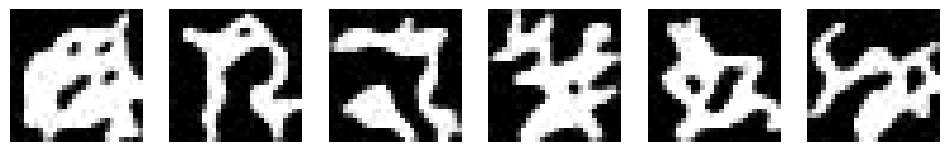

Epoch 11/100: 100%|██████████| 46/46 [00:00<00:00, 51.64it/s, loss=0.8320]


Epoch 11: Loss = 0.7841, LR = 0.000097


Epoch 12/100: 100%|██████████| 46/46 [00:00<00:00, 52.37it/s, loss=0.8277]


Epoch 12: Loss = 0.7726, LR = 0.000097


Epoch 13/100: 100%|██████████| 46/46 [00:00<00:00, 51.08it/s, loss=0.7691]


...

Epoch 18: Loss = 0.7602, LR = 0.000092


Epoch 19/100: 100%|██████████| 46/46 [00:00<00:00, 52.01it/s, loss=0.7397]


Epoch 19: Loss = 0.7451, LR = 0.000091


Epoch 20/100: 100%|██████████| 46/46 [00:00<00:00, 52.09it/s, loss=0.7901]


Epoch 20: Loss = 0.7476, LR = 0.000091
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


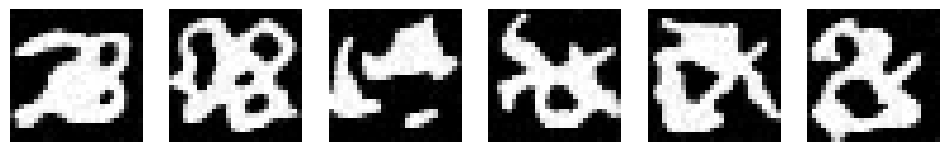

Epoch 21/100: 100%|██████████| 46/46 [00:01<00:00, 35.81it/s, loss=0.6854]


Epoch 21: Loss = 0.7484, LR = 0.000090


Epoch 22/100: 100%|██████████| 46/46 [00:00<00:00, 51.36it/s, loss=0.7697]


Epoch 22: Loss = 0.7504, LR = 0.000089


Epoch 23/100: 100%|██████████| 46/46 [00:00<00:00, 51.96it/s, loss=0.7855]


...

Epoch 28: Loss = 0.7384, LR = 0.000082


Epoch 29/100: 100%|██████████| 46/46 [00:00<00:00, 51.73it/s, loss=0.7407]


Epoch 29: Loss = 0.7404, LR = 0.000081


Epoch 30/100: 100%|██████████| 46/46 [00:00<00:00, 51.52it/s, loss=0.7081]


Epoch 30: Loss = 0.7355, LR = 0.000080
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


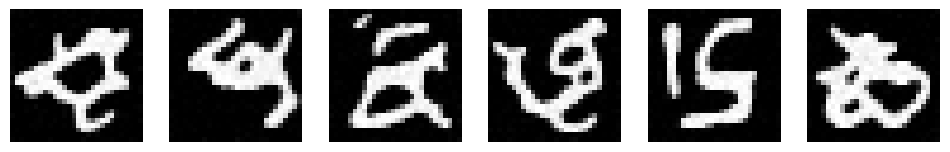

Epoch 31/100: 100%|██████████| 46/46 [00:00<00:00, 52.07it/s, loss=0.7384]


Epoch 31: Loss = 0.7311, LR = 0.000078


Epoch 32/100: 100%|██████████| 46/46 [00:00<00:00, 51.43it/s, loss=0.6752]


Epoch 32: Loss = 0.7257, LR = 0.000077


Epoch 33/100: 100%|██████████| 46/46 [00:00<00:00, 51.69it/s, loss=0.6672]


...

Epoch 38: Loss = 0.7195, LR = 0.000069


Epoch 39/100: 100%|██████████| 46/46 [00:00<00:00, 50.61it/s, loss=0.7286]


Epoch 39: Loss = 0.7269, LR = 0.000067


Epoch 40/100: 100%|██████████| 46/46 [00:00<00:00, 50.59it/s, loss=0.7603]


Epoch 40: Loss = 0.7177, LR = 0.000066
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


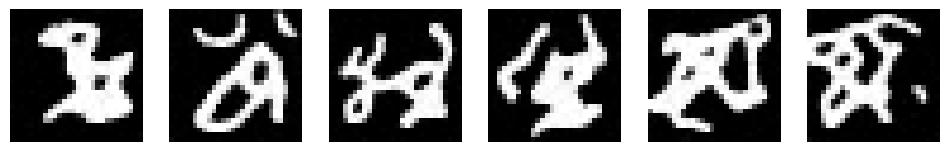

Epoch 41/100: 100%|██████████| 46/46 [00:00<00:00, 52.10it/s, loss=0.7386]


Epoch 41: Loss = 0.7170, LR = 0.000064


Epoch 42/100: 100%|██████████| 46/46 [00:00<00:00, 51.91it/s, loss=0.6851]


Epoch 42: Loss = 0.7141, LR = 0.000063


Epoch 43/100: 100%|██████████| 46/46 [00:00<00:00, 50.00it/s, loss=0.6677]


...

Epoch 48: Loss = 0.7143, LR = 0.000054


Epoch 49/100: 100%|██████████| 46/46 [00:00<00:00, 50.29it/s, loss=0.7267]


Epoch 49: Loss = 0.7156, LR = 0.000052


Epoch 50/100: 100%|██████████| 46/46 [00:00<00:00, 50.30it/s, loss=0.7041]


Epoch 50: Loss = 0.7151, LR = 0.000051
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


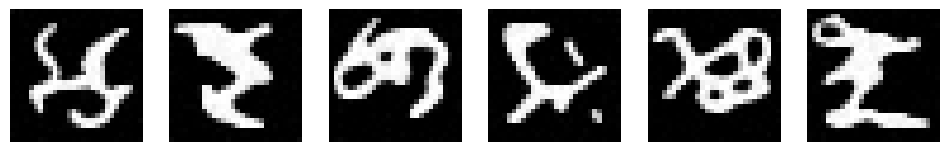

Checkpoint saved: dsm_model_epoch_50.pt


Epoch 51/100: 100%|██████████| 46/46 [00:00<00:00, 51.20it/s, loss=0.6916]


Epoch 51: Loss = 0.7144, LR = 0.000049


Epoch 52/100: 100%|██████████| 46/46 [00:00<00:00, 50.97it/s, loss=0.7172]


Epoch 52: Loss = 0.7119, LR = 0.000047


...

Epoch 58: Loss = 0.7119, LR = 0.000038


Epoch 59/100: 100%|██████████| 46/46 [00:00<00:00, 50.72it/s, loss=0.7065]


Epoch 59: Loss = 0.7064, LR = 0.000037


Epoch 60/100: 100%|██████████| 46/46 [00:00<00:00, 51.25it/s, loss=0.6859]


Epoch 60: Loss = 0.7093, LR = 0.000035
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


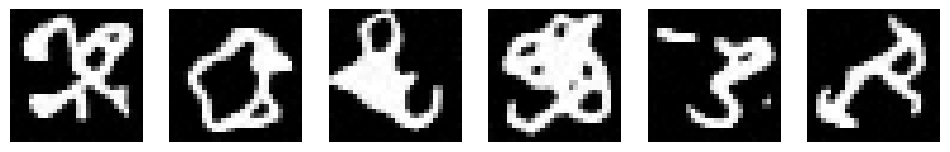

Epoch 61/100: 100%|██████████| 46/46 [00:00<00:00, 51.49it/s, loss=0.7300]


Epoch 61: Loss = 0.7086, LR = 0.000034


Epoch 62/100: 100%|██████████| 46/46 [00:00<00:00, 51.06it/s, loss=0.7371]


Epoch 62: Loss = 0.7130, LR = 0.000032


Epoch 63/100: 100%|██████████| 46/46 [00:00<00:00, 51.60it/s, loss=0.6577]


...

Epoch 68: Loss = 0.7074, LR = 0.000024


Epoch 69/100: 100%|██████████| 46/46 [00:00<00:00, 51.11it/s, loss=0.7270]


Epoch 69: Loss = 0.7065, LR = 0.000023


Epoch 70/100: 100%|██████████| 46/46 [00:00<00:00, 51.29it/s, loss=0.7094]


Epoch 70: Loss = 0.7030, LR = 0.000021
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


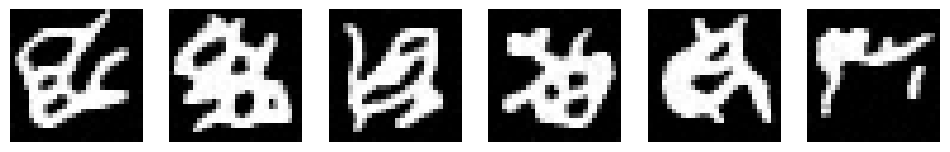

Epoch 71/100: 100%|██████████| 46/46 [00:00<00:00, 50.02it/s, loss=0.6432]


Epoch 71: Loss = 0.7146, LR = 0.000020


Epoch 72/100: 100%|██████████| 46/46 [00:00<00:00, 50.72it/s, loss=0.7075]


Epoch 72: Loss = 0.7030, LR = 0.000019


Epoch 73/100: 100%|██████████| 46/46 [00:00<00:00, 52.13it/s, loss=0.7099]


...

Epoch 78: Loss = 0.6992, LR = 0.000012


Epoch 79/100: 100%|██████████| 46/46 [00:00<00:00, 52.48it/s, loss=0.6889]


Epoch 79: Loss = 0.6951, LR = 0.000011


Epoch 80/100: 100%|██████████| 46/46 [00:00<00:00, 50.80it/s, loss=0.6521]


Epoch 80: Loss = 0.7050, LR = 0.000010
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


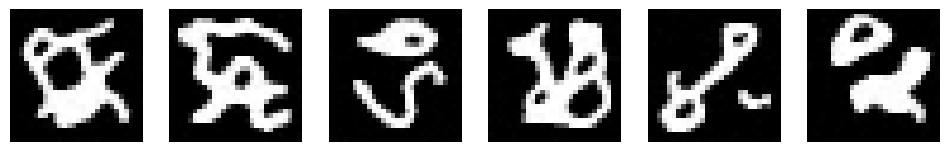

Epoch 81/100: 100%|██████████| 46/46 [00:00<00:00, 50.59it/s, loss=0.6815]


Epoch 81: Loss = 0.7058, LR = 0.000010


Epoch 82/100: 100%|██████████| 46/46 [00:00<00:00, 50.94it/s, loss=0.6718]


Epoch 82: Loss = 0.6994, LR = 0.000009


Epoch 83/100: 100%|██████████| 46/46 [00:00<00:00, 50.16it/s, loss=0.7389]


...

Epoch 88: Loss = 0.6957, LR = 0.000004


Epoch 89/100: 100%|██████████| 46/46 [00:00<00:00, 51.95it/s, loss=0.7084]


Epoch 89: Loss = 0.6970, LR = 0.000004


Epoch 90/100: 100%|██████████| 46/46 [00:00<00:00, 51.62it/s, loss=0.6653]


Epoch 90: Loss = 0.6926, LR = 0.000003
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


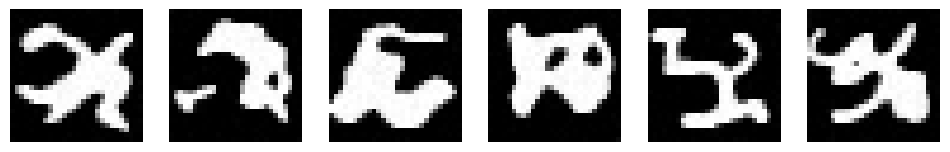

Epoch 91/100: 100%|██████████| 46/46 [00:00<00:00, 50.80it/s, loss=0.6587]


Epoch 91: Loss = 0.7000, LR = 0.000003


Epoch 92/100: 100%|██████████| 46/46 [00:00<00:00, 50.40it/s, loss=0.7262]


Epoch 92: Loss = 0.7003, LR = 0.000003


Epoch 93/100: 100%|██████████| 46/46 [00:00<00:00, 51.21it/s, loss=0.6906]


...

Epoch 98: Loss = 0.7012, LR = 0.000001


Epoch 99/100: 100%|██████████| 46/46 [00:00<00:00, 51.58it/s, loss=0.7255]


Epoch 99: Loss = 0.7044, LR = 0.000001


Epoch 100/100: 100%|██████████| 46/46 [00:00<00:00, 51.23it/s, loss=0.6674]


Epoch 100: Loss = 0.6999, LR = 0.000001
Generating samples...
 Step 1/500, t=1.0000, noise SD=1.00
 Step 200/500, t=0.6012, noise SD=0.60
 Step 400/500, t=0.2004, noise SD=0.20


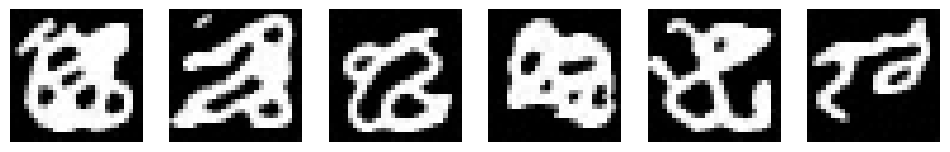

Checkpoint saved: dsm_model_epoch_100.pt


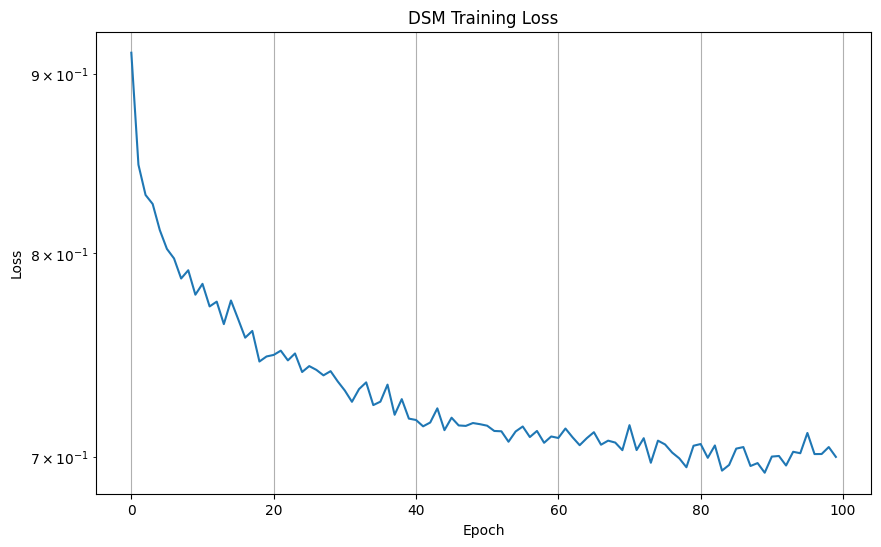

(ScoreNet(
   (convs): ModuleList(
     (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (4): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (5): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (6): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (7): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   )
   (norms): ModuleList(
     (0): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, a

In [ ]:
train_score_model(model, train_loader, device, num_epochs = 100)

### Question: _What do you observe as the training progress?_

DSM training loss has a downward trend, which is good. However, by inspecting the generated images, throughout the 100 epochs (including the final epochs) there was nothing that look like a figure 8 (instead they look more like Japanese characters). 

---

### Experiment: VE-consistent reverse sampler (no retraining) (suggested by Claude)
`dsm_loss` trains the score net on a Variance-Exploding (VE) corruption (`x_noisy = x + sigma*noise`, no attenuation of `x`), but `sample_from_model`'s reverse SDE uses the Variance-Preserving (VP) drift `-0.5*beta_t*x - beta_t*score` from the assignment markdown, which assumes `x`'s mean shrinks toward zero during the forward process. That mismatch is a likely cause of the samples looking locally stroke-like but globally incoherent (the two "8" loops not connecting into a consistent shape).

The cells below define an alternate reverse sampler consistent with the VE process actually used in training (`sigma(t) = t`, so `g(t)^2 = 2t`, dropping the mean-reverting drift term entirely), and generate samples directly from the already-trained `model` object — no retraining needed.


In [ ]:
@torch.no_grad()
def sample_from_model_ve(score_net, shape, device, num_steps=1000):
    score_net.eval()

    x = torch.randn(shape, device=device)
    # log-spaced steps: matches the log-uniform sigma sampling used in training,
    # giving far more step density near small sigma where fine detail is resolved
    t_steps = torch.logspace(0, -6, num_steps, device=device)  # 1.0 -> 1e-6

    for i in range(num_steps - 1):
        t, t_next = t_steps[i], t_steps[i+1]
        dt = t_next - t

        sigma = t
        g2 = 2 * t  # g(t)^2 = d(sigma(t)^2)/dt with sigma(t) = t (VE-SDE)

        score = score_net(x, sigma.view(1, 1, 1, 1).expand(shape[0], 1, 1, 1))

        drift = -g2 * score
        diffusion = torch.sqrt(g2)

        # skip injecting noise on the very last step so the trajectory ends on a clean denoise
        z = torch.randn_like(x) if i < num_steps - 2 else torch.zeros_like(x)
        x = x + drift * dt + diffusion * torch.sqrt(-dt) * z

        if (i+1) % 200 == 0 or i == 0:
            print(f" Step {i+1}/{num_steps}, t={t:.4f}, noise SD={sigma:.2f}")

    return x

 Step 1/1000, t=1.0000, noise SD=1.00
 Step 200/1000, t=0.0638, noise SD=0.06
 Step 400/1000, t=0.0040, noise SD=0.00
 Step 600/1000, t=0.0003, noise SD=0.00
 Step 800/1000, t=0.0000, noise SD=0.00


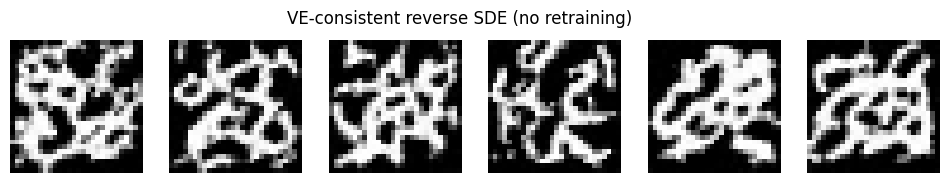

In [ ]:
# Safety net: if the kernel was restarted since training, reload the last checkpoint
# instead of retraining. Skips silently if `model` is already in memory from this session.
if 'model' not in globals():
    import glob
    ckpts = sorted(glob.glob('dsm_model_epoch_*.pt'))
    assert ckpts, "No checkpoint found in the current working directory."
    model = ScoreNet(embed_dim=64).to(device)
    model.load_state_dict(torch.load(ckpts[-1], map_location=device)['model_state_dict'])
    print(f"Loaded checkpoint: {ckpts[-1]}")

model.eval()
samples_ve = sample_from_model_ve(model, (6, 1, 28, 28), device, num_steps=1000)
samples_ve = torch.clamp(samples_ve, -1, 1)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(samples_ve[i, 0].cpu().numpy(), cmap='gray')
    axes[i].axis('off')
plt.suptitle('VE-consistent reverse SDE (no retraining)')
plt.show()